In [1]:
%load_ext sql

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("SQL Magic: READY")
print("Pandas: READY")
print("Seaborn: READY")

SQL Magic: READY
Pandas: READY
Seaborn: READY


In [2]:
%sql sqlite:///MY_SQL_MAGIC_PRACTICE.db

In [3]:
%sql SELECT name FROM sqlite_master WHERE type='table';

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


name
SALES_PERFORMANCE


In [ ]:
%%sql

DROP TABLE IF EXISTS SALES_PERFORMANCE;

CREATE TABLE SALES_PERFORMANCE (
    employee_id INTEGER,
    employee_name VARCHAR(50),
    department VARCHAR(30),
    city VARCHAR(30),
    sales_amount REAL
);

INSERT INTO SALES_PERFORMANCE VALUES
(101, 'Arun', 'Sales', 'Kochi', 125000),
(102, 'Meera', 'Sales', 'Chennai', 148000),
(103, 'Rahul', 'Marketing', 'Bengaluru', 98000),
(104, 'Anita', 'Sales', 'Mumbai', 172000),
(105, 'Vivek', 'Marketing', 'Kochi', 115000),
(106, 'Priya', 'Sales', 'Delhi', 156000),
(107, 'Suresh', 'Finance', 'Chennai', 87000),
(108, 'Neha', 'Marketing', 'Mumbai', 132000);

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.
Done.
8 rows affected.


[]

In [ ]:
%%sql
SELECT * FROM SALES_PERFORMANCE;

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


employee_id,employee_name,department,city,sales_amount
101,Arun,Sales,Kochi,125000.0
102,Meera,Sales,Chennai,148000.0
103,Rahul,Marketing,Bengaluru,98000.0
104,Anita,Sales,Mumbai,172000.0
105,Vivek,Marketing,Kochi,115000.0
106,Priya,Sales,Delhi,156000.0
107,Suresh,Finance,Chennai,87000.0
108,Neha,Marketing,Mumbai,132000.0


In [ ]:
%%sql

SELECT *
FROM SALES_PERFORMANCE;

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


employee_id,employee_name,department,city,sales_amount
101,Arun,Sales,Kochi,125000.0
102,Meera,Sales,Chennai,148000.0
103,Rahul,Marketing,Bengaluru,98000.0
104,Anita,Sales,Mumbai,172000.0
105,Vivek,Marketing,Kochi,115000.0
106,Priya,Sales,Delhi,156000.0
107,Suresh,Finance,Chennai,87000.0
108,Neha,Marketing,Mumbai,132000.0


In [ ]:
department = "Sales"

%sql SELECT * FROM SALES_PERFORMANCE WHERE department = :department


 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


employee_id,employee_name,department,city,sales_amount
101,Arun,Sales,Kochi,125000.0
102,Meera,Sales,Chennai,148000.0
104,Anita,Sales,Mumbai,172000.0
106,Priya,Sales,Delhi,156000.0


In [ ]:
sales_summary = %sql SELECT department, SUM(sales_amount) AS total_sales, AVG(sales_amount) AS average_sales FROM SALES_PERFORMANCE GROUP BY department ORDER BY total_sales DESC 

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


In [ ]:
sales_summary = %sql SELECT department, SUM(sales_amount) AS total_sales, AVG(sales_amount) AS average_sales FROM SALES_PERFORMANCE GROUP BY department ORDER BY total_sales DESC

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


In [ ]:
sales_df = sales_summary.DataFrame()

print(sales_df)
print()
print("Shape:", sales_df.shape)

  department  total_sales  average_sales
0      Sales     601000.0       150250.0
1  Marketing     345000.0       115000.0
2    Finance      87000.0        87000.0

Shape: (3, 3)


In [ ]:
print("Total Sales:", sales_df["total_sales"].sum())
print("Highest Department Sales:", sales_df["total_sales"].max()) 

Total Sales: 1033000.0
Highest Department Sales: 601000.0


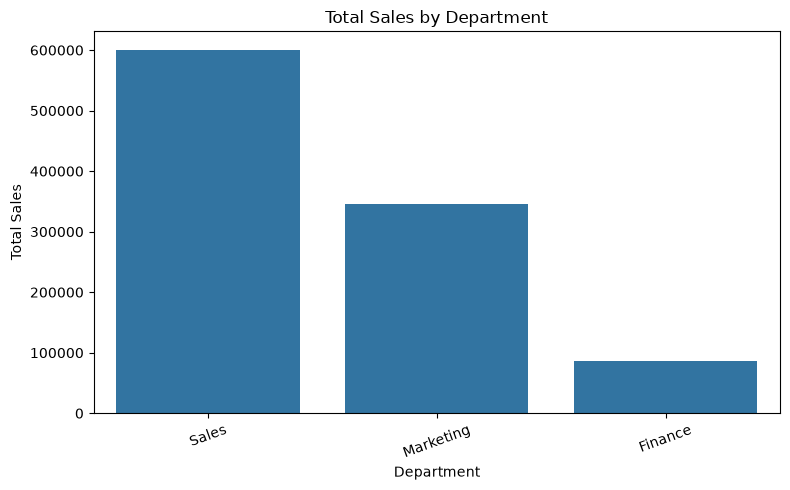

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x="department",
    y="total_sales",
    data=sales_df
)

plt.title("Total Sales by Department")
plt.xlabel("Department")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show() 

In [ ]:
%%sql

SELECT
    city,
    COUNT(*) AS employee_count,
    ROUND(AVG(sales_amount), 2) AS average_sales
FROM SALES_PERFORMANCE
GROUP BY city
ORDER BY average_sales DESC;

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


city,employee_count,average_sales
Delhi,1,156000.0
Mumbai,2,152000.0
Kochi,2,120000.0
Chennai,2,117500.0
Bengaluru,1,98000.0


In [ ]:
import prettytable
import sql

print("PrettyTable version:", prettytable.__version__)
print("ipython-sql: OK")

%config SqlMagic.style = "DEFAULT"
print("SQL Magic style: DEFAULT")

PrettyTable version: 3.10.2
ipython-sql: OK
SQL Magic style: DEFAULT


In [4]:
%load_ext sql

In [5]:
%sql sqlite:///MY_SQL_MAGIC_PRACTICE.db

In [6]:
%sql SELECT COUNT(*) AS record_count FROM SALES_PERFORMANCE;

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.


record_count
8


In [7]:
city_analysis = %sql SELECT city, COUNT(*) AS employee_count, SUM(sales_amount) AS total_sales, AVG(sales_amount) AS average_sales FROM SALES_PERFORMANCE GROUP BY city ORDER BY total_sales DESC

print(city_analysis)

 * sqlite:///MY_SQL_MAGIC_PRACTICE.db
Done.
+-----------+----------------+-------------+---------------+
|    city   | employee_count | total_sales | average_sales |
+-----------+----------------+-------------+---------------+
|   Mumbai  |       2        |   304000.0  |    152000.0   |
|   Kochi   |       2        |   240000.0  |    120000.0   |
|  Chennai  |       2        |   235000.0  |    117500.0   |
|   Delhi   |       1        |   156000.0  |    156000.0   |
| Bengaluru |       1        |   98000.0   |    98000.0    |
+-----------+----------------+-------------+---------------+
